# Attendance and Exam Score Prediction
Multiple linear regression using ten inputs. Dataset: [Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors). These are synthetic records.

**Perni Bharath Raghavendra** · Mark Zuckerberg Cohort · Roll number: 150096724139

[GitHub repository](https://github.com/bharath-541/Attendance-and-Exam-Score-Prediction-Using-Linear-Regression) | [Streamlit application](https://bharath-attendance-exam-score.streamlit.app/)

### 1. Import libraries

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 2. Load the dataset

In [2]:
data_path = Path('data/StudentPerformanceFactors.csv')
source = 'https://www.kaggle.com/api/v1/datasets/download/lainguyn123/student-performance-factors?datasetVersionNumber=9'
raw = pd.read_csv(data_path) if data_path.exists() else pd.read_csv(source, compression='zip')
raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### 3. Select inputs and clean records

In [3]:
NUMERIC = ['Attendance', 'Hours_Studied', 'Previous_Scores',
           'Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity']
CATEGORICAL = ['Access_to_Resources', 'Motivation_Level',
               'Internet_Access', 'Extracurricular_Activities']
FEATURES = NUMERIC + CATEGORICAL
TARGET = 'Exam_Score'
clean = raw.drop_duplicates().copy()
clean = clean.loc[clean[TARGET].between(0, 100)]
clean[FEATURES + [TARGET]].isna().sum()

Attendance                    0
Hours_Studied                 0
Previous_Scores               0
Sleep_Hours                   0
Tutoring_Sessions             0
Physical_Activity             0
Access_to_Resources           0
Motivation_Level              0
Internet_Access               0
Extracurricular_Activities    0
Exam_Score                    0
dtype: int64

The selected columns have no missing values, so imputation is unnecessary. We assume scores are on a 0–100 scale and exclude the one record with score 101.

### 4. Split training and test data

In [4]:
X = clean[FEATURES]
y = clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Training records:', len(X_train))
print('Test records:', len(X_test))

Training records: 5284
Test records: 1322


### 5. Encode categorical inputs

In [5]:
encoder = ColumnTransformer([
    ('numeric', 'passthrough', NUMERIC),
    ('categorical', OneHotEncoder(drop='first', sparse_output=False), CATEGORICAL)
])
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

One-hot encoding converts categories into binary columns without assigning an artificial order. Fit the encoder on training data only; use the same encoder on test data.

### 6. Train linear regression

In [6]:
model = LinearRegression()
model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0.2 , 0.29, 0.05,...,-0.54, 0.93, 0.54]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[1044.48, 837.9 , 433.7 ,..., 22.33, 20.33, 19.07]"


### 7. Predict and evaluate

In [7]:
y_pred = model.predict(X_test_encoded)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print('MAE:', round(mae, 3))
print('RMSE:', round(rmse, 3))
print('R²:', round(r2, 3))

MAE: 1.016
RMSE: 1.876
R²: 0.734


MAE measures average absolute error in score points. RMSE penalizes larger errors more strongly. R² compares predictions with predicting the test-set mean; higher is better.

### 8. Plot attendance and achievement

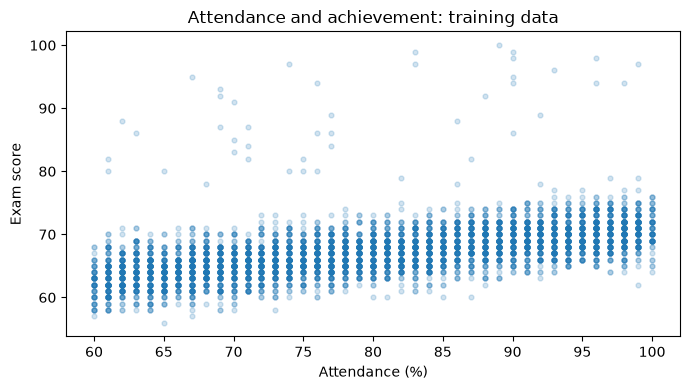

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(X_train['Attendance'], y_train, alpha=0.2, s=12)
plt.xlabel('Attendance (%)')
plt.ylabel('Exam score')
plt.title('Attendance and achievement: training data')
plt.tight_layout()
plt.show()

### 9. Plot actual and predicted scores

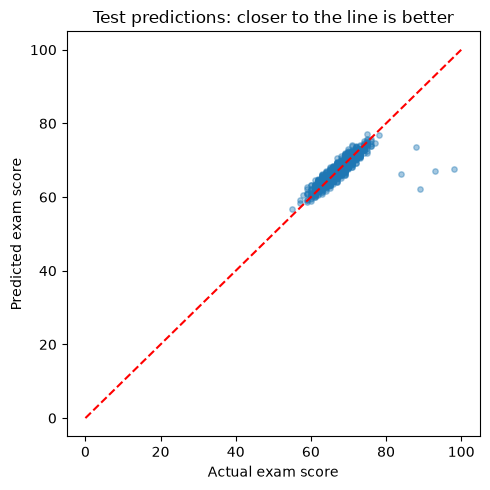

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.4, s=15)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Actual exam score')
plt.ylabel('Predicted exam score')
plt.title('Test predictions: closer to the line is better')
plt.tight_layout()
plt.show()

### 10. Test one student profile

In [10]:
student = pd.DataFrame([{
    'Attendance': 80, 'Hours_Studied': 20, 'Previous_Scores': 75,
    'Sleep_Hours': 7, 'Tutoring_Sessions': 1, 'Physical_Activity': 3,
    'Access_to_Resources': 'Medium', 'Motivation_Level': 'Medium',
    'Internet_Access': 'Yes', 'Extracurricular_Activities': 'No'
}])
score = model.predict(encoder.transform(student))[0]
print('Predicted exam score:', round(score, 2))

Predicted exam score: 66.72


### 11. Export the model

In [11]:
joblib.dump({'encoder': encoder, 'model': model, 'features': FEATURES}, 'model.joblib')
results = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
Path('results.json').write_text(json.dumps(results, indent=2))
print('Model saved as model.joblib')

Model saved as model.joblib
